# NeuroShield AI — SHAP Explainability: Deep Learning

**Model:** TabNet  
**Target:** `Ever_told_you_had_a_stroke`

This notebook performs model-agnostic SHAP explainability for the saved TabNet model. It uses a smaller reproducible sample because model-agnostic SHAP is computationally more expensive than tree-specific SHAP.

In [1]:
# Install once if needed
# %pip install shap pytorch-tabnet pandas numpy matplotlib scikit-learn

In [2]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from pytorch_tabnet.tab_model import TabNetClassifier

DATA_PATH = "../dataset/processed/transformed_train.csv"
MODEL_PATH = "../models/tabnet_stroke_model.zip"
FIG_DIR = "../research_figures"
SHAP_DIR = "../models/shap"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(SHAP_DIR, exist_ok=True)

print("SHAP:", shap.__version__)

SHAP: 0.52.0


In [3]:
tabnet = TabNetClassifier()
tabnet.load_model(MODEL_PATH)

df = pd.read_csv(DATA_PATH)
TARGET = "ever_told_you_had_a_stroke"



def clean_column_name(col):
    col = re.sub(r'^(binary|multi|ordinal|remainder)__', '', col)
    col = re.sub(r'[^A-Za-z0-9_]+', '_', col)
    col = re.sub(r'_+', '_', col)
    return col.strip('_').lower()

df.columns = [clean_column_name(c) for c in df.columns]
X = df.drop(columns=[TARGET]).copy()

print("TabNet loaded")
print("X shape:", X.shape)

C:\Users\nitya\AppData\Roaming\Python\Python312\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


TabNet loaded
X shape: (345242, 47)


In [4]:
# Smaller sample for model-agnostic SHAP
X_shap = X.sample(n=min(500, len(X)), random_state=42).copy()
X_background = X_shap.sample(n=min(50, len(X_shap)), random_state=42).copy()

print("Explanation sample:", X_shap.shape)
print("Background:", X_background.shape)

Explanation sample: (500, 47)
Background: (50, 47)


In [5]:
def tabnet_predict(data):
    data = np.asarray(data, dtype=np.float32)
    return tabnet.predict_proba(data)[:, 1]

print("Test probabilities:", tabnet_predict(X_shap.iloc[:5]))

Test probabilities: [0.880315   0.7355397  0.01271425 0.6295013  0.50928056]


In [6]:
# TabNet is not a tree model; use a model-agnostic explainer.
masker = shap.maskers.Independent(X_background)
explainer = shap.Explainer(tabnet_predict, masker)

max_evals = 2 * X_shap.shape[1] + 1
shap_values = explainer(X_shap, max_evals=max_evals)

print("SHAP values:", shap_values.values.shape)

PermutationExplainer explainer: 501it [01:52,  4.39it/s]                         

SHAP values: (500, 47)


In [7]:
importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
importance["rank"] = np.arange(1, len(importance) + 1)

display(importance.head(20))
importance.to_csv(f"{SHAP_DIR}/shap_tabnet_feature_importance.csv", index=False)

,feature,mean_abs_shap,rank
0,imputed_age_value_collapsed_above_80,0.058875,1
1,are_you_currently_taking_medicine_prescribed_b...,0.053694,2
2,would_you_say_that_in_general_your_health_is,0.051574,3
3,adults_who_have_been_told_they_have_high_blood...,0.049232,4
4,respondents_that_have_ever_reported_having_cor...,0.046816,5
5,ever_told_you_had_a_heart_attack_also_called_a...,0.020521,6
6,are_you_currently_retired,0.019151,7
7,are_you_currently_unable_to_work,0.015959,8
8,have_you_ever_been_told_by_a_doctor_nurse_or_o...,0.014888,9
9,is_your_annual_household_income_from_all_sourc...,0.012186,10


C:\Users\nitya\AppData\Local\Temp\ipykernel_10228\333238471.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
C:\Users\nitya\AppData\Roaming\Python\Python312\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\nitya\AppData\Local\Temp\ipykernel_10228\333238471.py:3: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


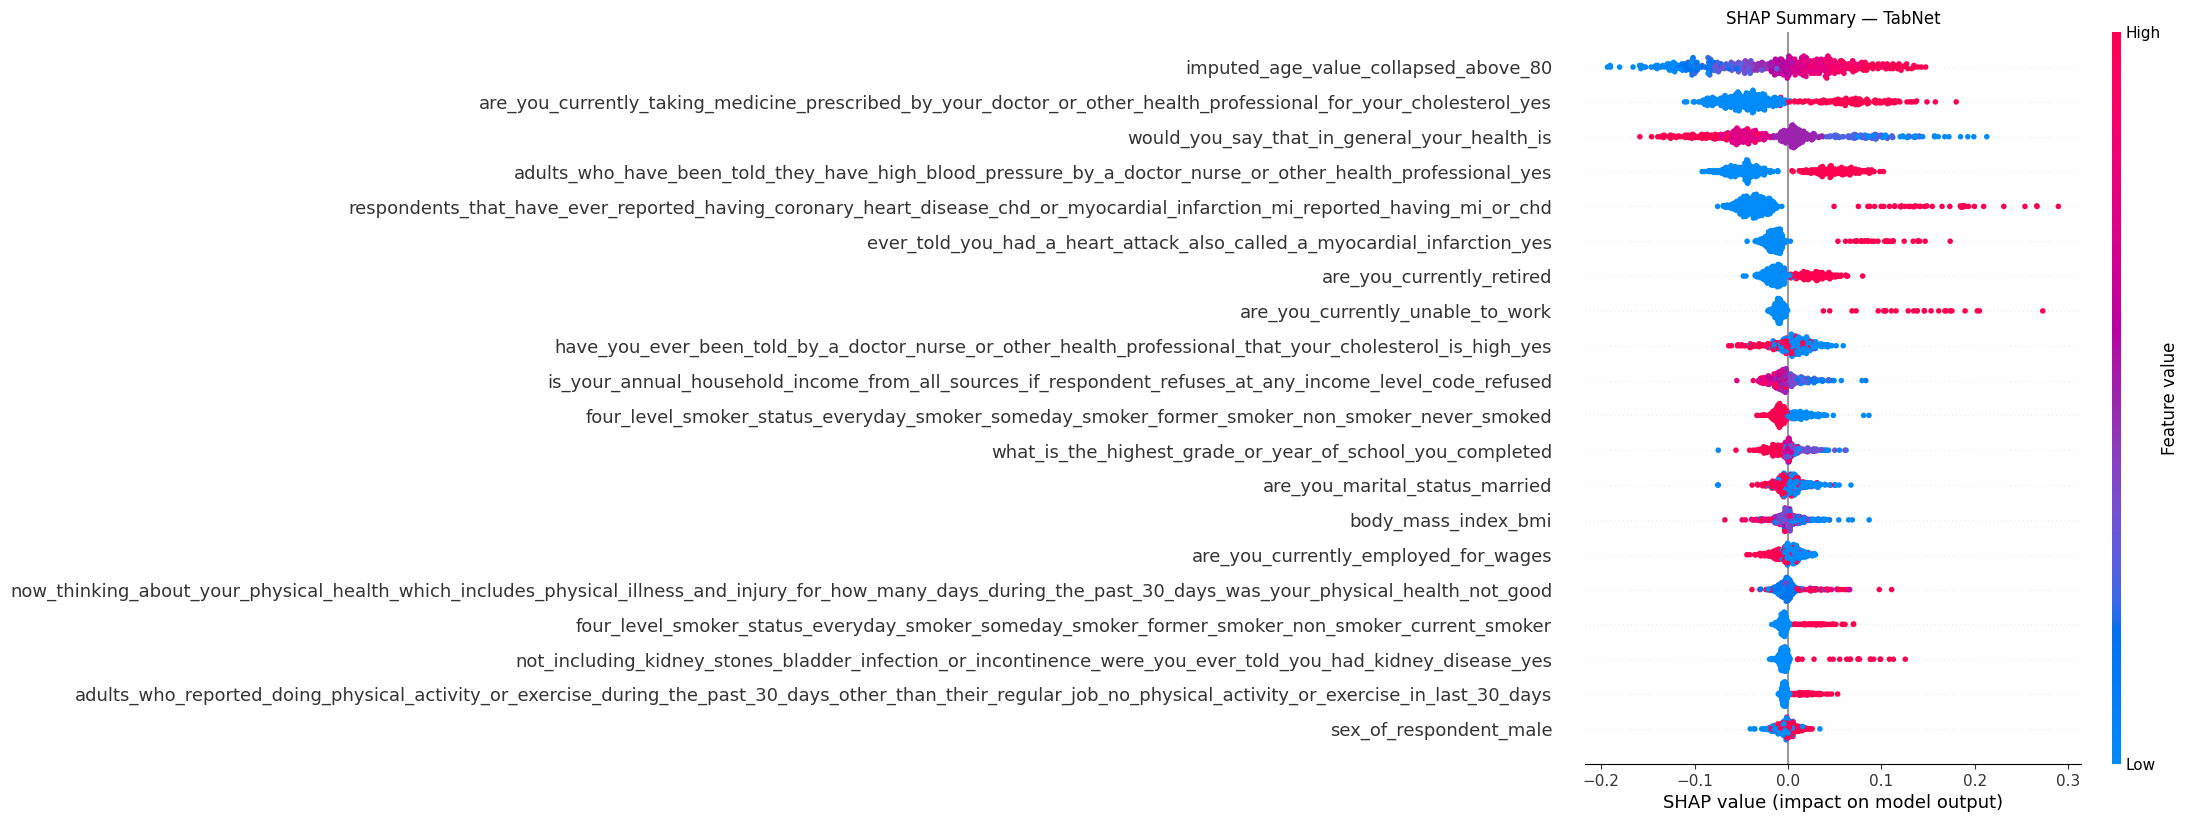

In [8]:
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.title("SHAP Summary — TabNet")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig14_shap_tabnet_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\nitya\AppData\Local\Temp\ipykernel_10228\2381737009.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=20, show=False)
C:\Users\nitya\AppData\Roaming\Python\Python312\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\nitya\AppData\Local\Temp\ipykernel_10228\2381737009.py:3: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


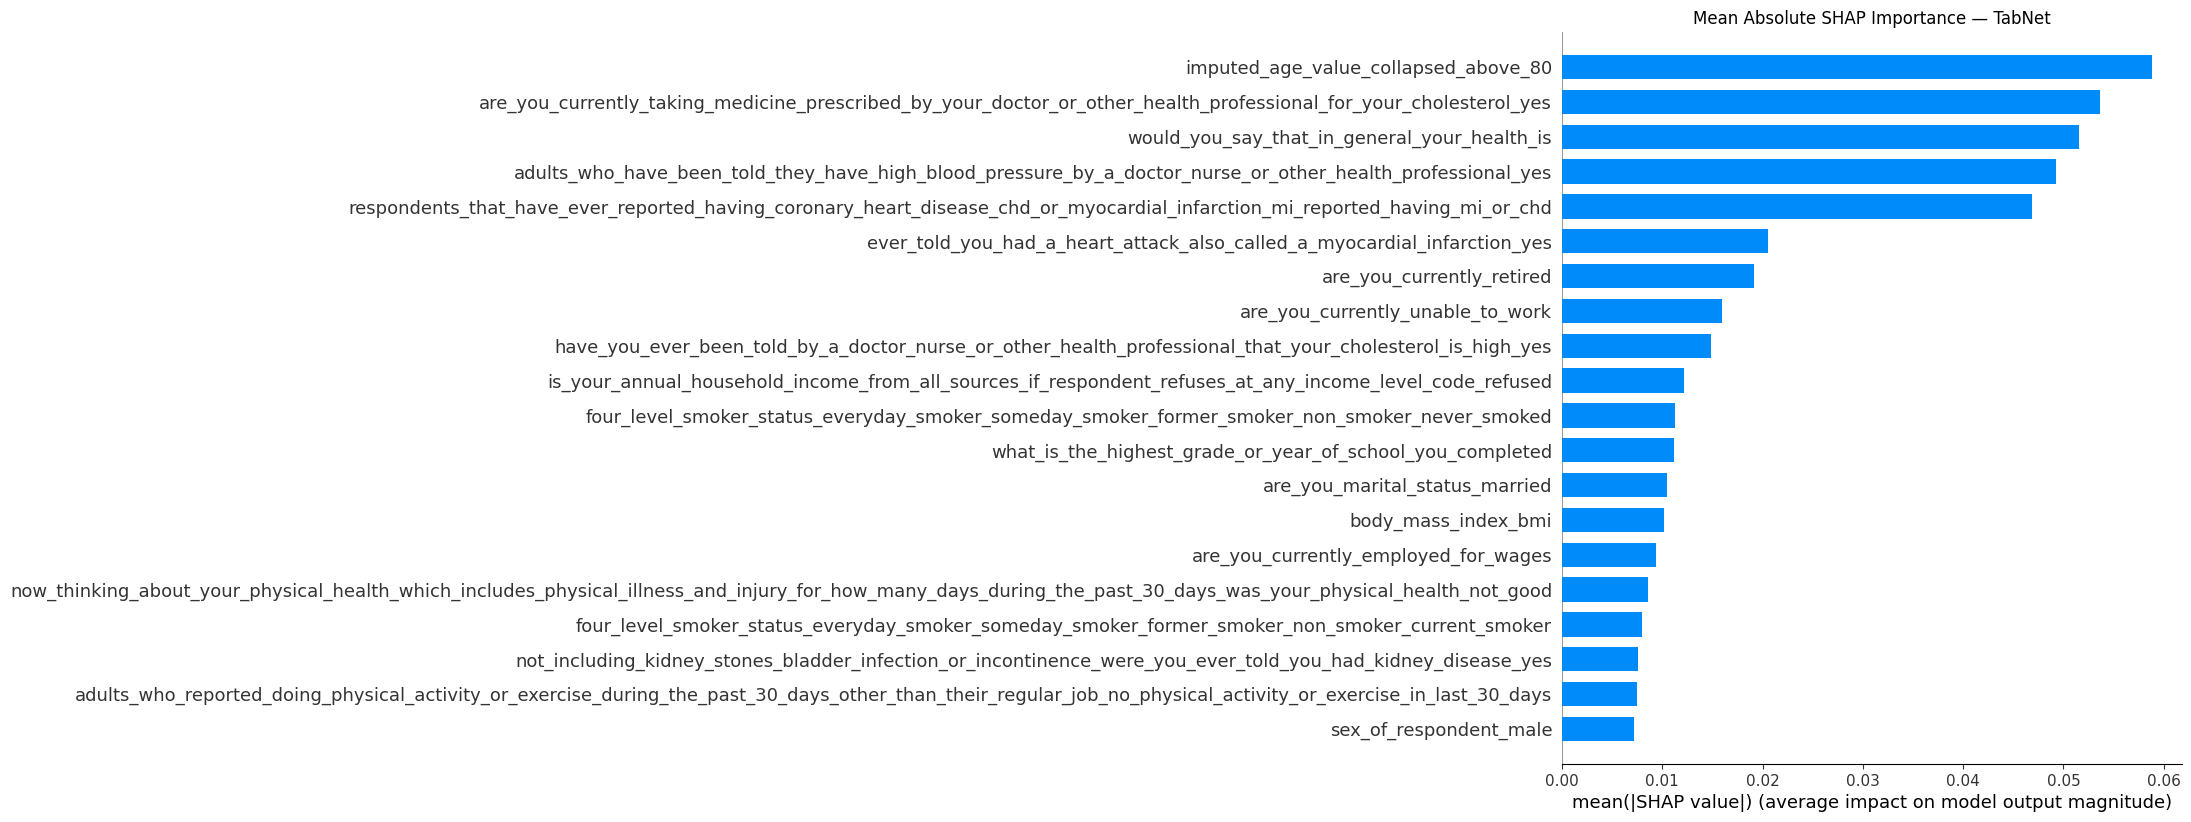

In [9]:
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=20, show=False)
plt.title("Mean Absolute SHAP Importance — TabNet")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig15_shap_tabnet_bar.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\nitya\AppData\Local\Temp\ipykernel_10228\1046306667.py:2: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


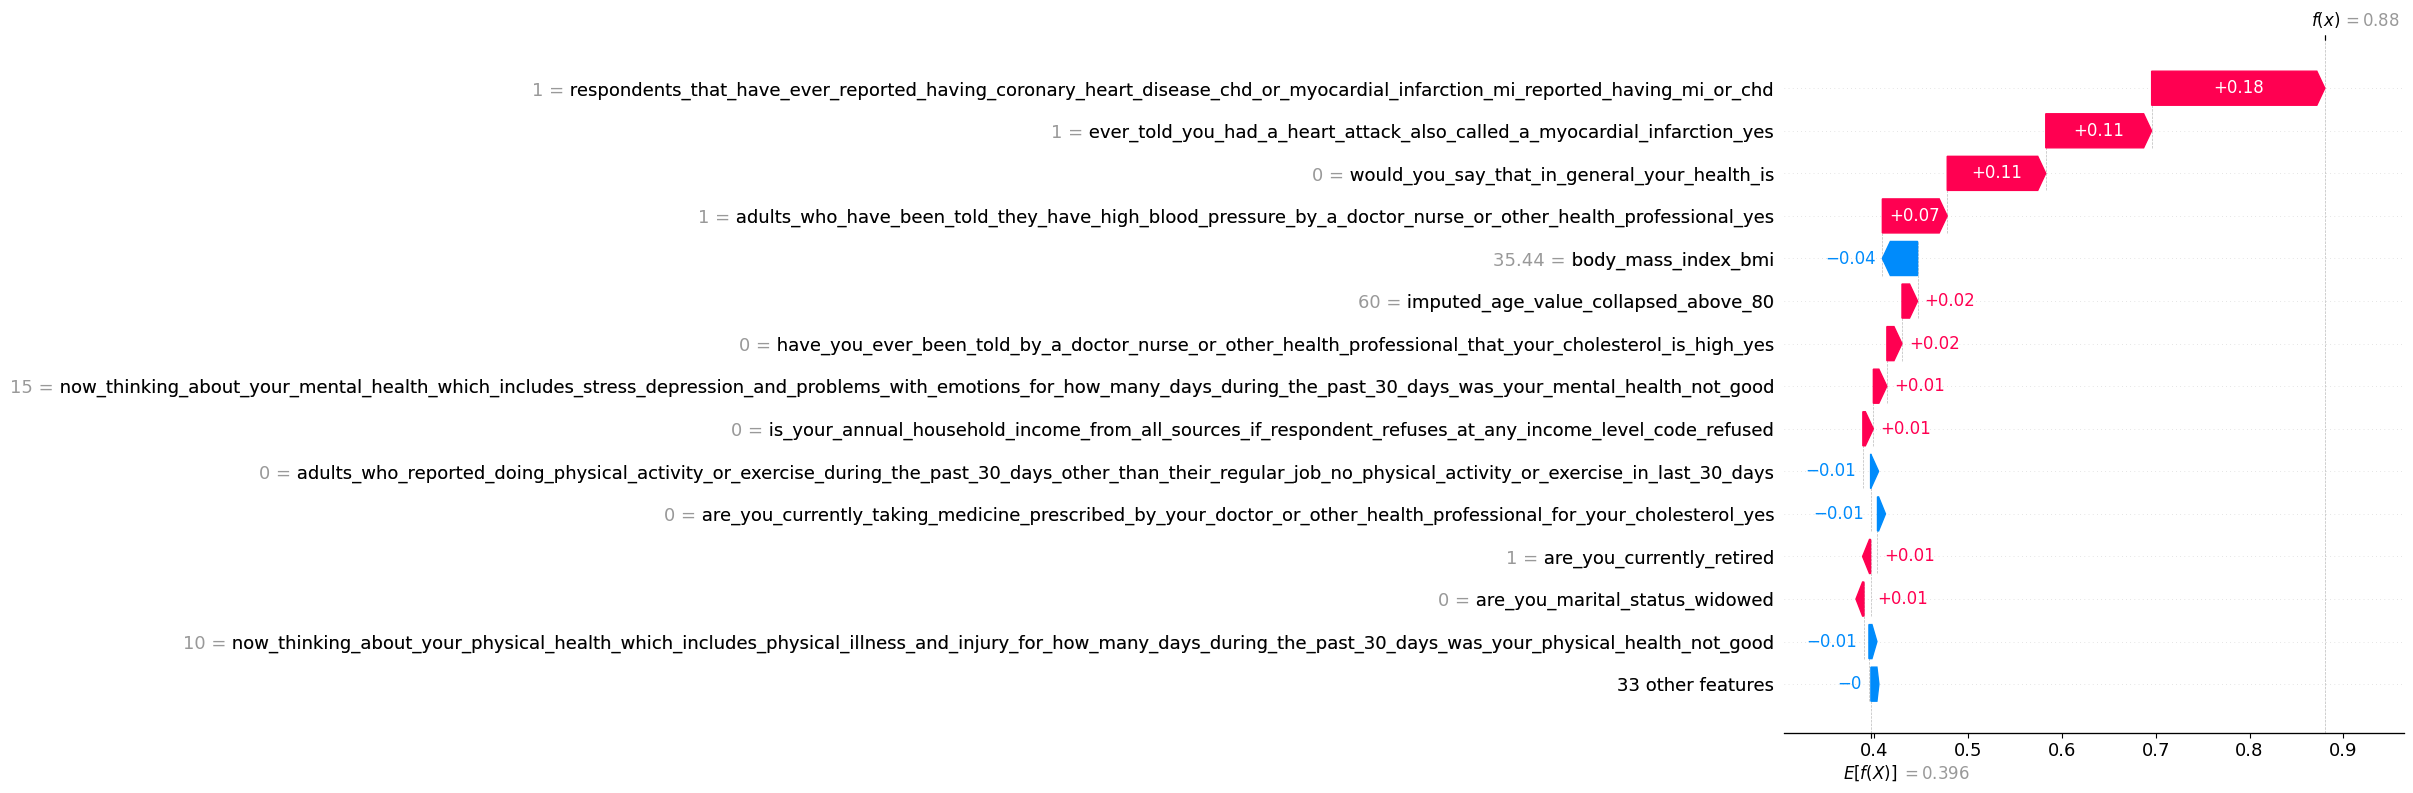

In [10]:
shap.plots.waterfall(shap_values[0], max_display=15, show=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig16_shap_tabnet_waterfall.png", dpi=300, bbox_inches="tight")
plt.show()

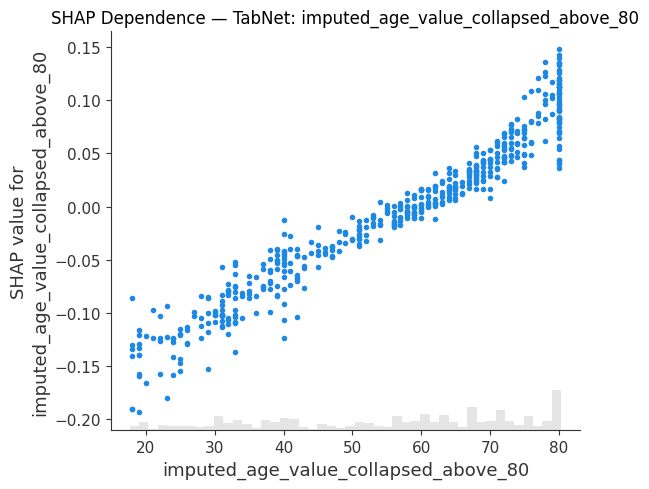

In [11]:
top_feature = importance.iloc[0]["feature"]
shap.plots.scatter(shap_values[:, top_feature], show=False)
plt.title(f"SHAP Dependence — TabNet: {top_feature}")
plt.tight_layout()
safe = re.sub(r"[^A-Za-z0-9_]+", "_", top_feature)
plt.savefig(f"{FIG_DIR}/fig17_shap_tabnet_dependence_{safe}.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
pd.DataFrame(shap_values.values, columns=X_shap.columns).to_csv(
    f"{SHAP_DIR}/shap_tabnet_values.csv", index=False)
X_shap.to_csv(f"{SHAP_DIR}/shap_tabnet_sample.csv", index=False)
print("TabNet SHAP outputs saved.")

TabNet SHAP outputs saved.


## Research interpretation

Report mean absolute SHAP values for global influence, the beeswarm for direction and magnitude, the dependence plot for the most influential feature, and the waterfall for an example prediction.

These explanations describe TabNet's behavior under the selected background distribution and sample. They do not establish causality or direct clinical risk.